In [ ]:
#Natural Langage Preprocessing
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
#from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [ ]:
df=pd.read_csv("/content/nlp_dataset.csv")
df

,Text
0,Natural Language Processing is a fascinating f...
1,It bridges the gap between humans and machines...
2,NLP techniques are widely used in applications...
3,Machine translation and speech recognition are...
4,"Despite its advancements, NLP faces challenges..."
5,Continuous research and innovation are improvi...
6,"The potential of NLP is vast, making it essent..."


In [ ]:
#Download required NLTK resources
nltk.download('punkt')#TOKENIZER
nltk.download('stopwords')#STOPWORDS
nltk.download('wordnet')#
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
#initialize stopwords and lemmatizer
stop_words=set(stopwords.words('english'))
print(stop_words)
lemmatizer=WordNetLemmatizer()

{"you're", 'theirs', "they'll", 'than', 'o', 'once', 'more', 'these', 'myself', 'was', 'me', 'under', "isn't", 'the', 'and', 'been', 'both', 'where', 'as', 'is', 'not', "we'll", 'what', 'there', 'mustn', 'herself', 'but', 'off', 'has', "needn't", 'for', 'wouldn', 'below', 'himself', 'did', 'up', 'wasn', 'we', 'shan', 'while', 'after', "didn't", 'into', "hadn't", 'a', 'had', 'having', 'm', 'all', "doesn't", 'no', 'in', "she's", 'this', 'down', 'd', 'other', 'you', 'didn', 'i', 'yourselves', 'because', 'll', 'have', 't', 'ain', 'be', 'few', 'further', "i'll", 'don', 'it', "she'd", "you'd", 'some', "don't", 'ourselves', 'weren', 'he', 'your', 'of', 'with', 'am', 'until', 'to', 'she', 'hasn', "she'll", "aren't", 'same', 'nor', 'yours', 'through', "hasn't", 'his', 've', 'being', 'does', 'aren', 'isn', 'doesn', "mightn't", 'my', 'at', 'him', "you'll", 'their', "shan't", 'own', "we're", 'between', 'those', "mustn't", 'now', 'from', 'hadn', 'itself', 'whom', 'its', 'hers', 'her', 'when', "it's

In [ ]:
def process_text(text):
  word_tokens=word_tokenize(text)
  filtered_tokens=[words for words in word_tokens if words.lower() not in stop_words]
  lemmatized_tokens=[lemmatizer.lemmatize(word.lower()) for word in filtered_tokens]

  return{
      "Original_Text":text,
      "Word_Tokens":word_tokens,
      "Filtered_Tokens":filtered_tokens,
      "Lemmatized_Tokens":lemmatized_tokens,
  }
results=df['Text'].apply(process_text)
processed_df=pd.DataFrame(results.tolist())
print(processed_df.head())
processed_file_path="/content/nlp_dataset.csv"
processed_df.to_csv(processed_file_path,index=False)
print(f"Processed data saved to {processed_file_path}")

                                       Original_Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   

                                         Word_Tokens  \
0  [Natural, Language, Processing, is, a, fascina...   
1  [It, bridges, the, gap, between, humans, and, ...   
2  [NLP, techniques, are, widely, used, in, appli...   
3  [Machine, translation, and, speech, recognitio...   
4  [Despite, its, advancements, ,, NLP, faces, ch...   

                                     Filtered_Tokens  \
0  [Natural, Language, Processing, fascinating, f...   
1  [bridges, gap, humans, machines, enabling, com...   
2  [NLP, techniques, widely, used, applications, ...   
3  [Machine, translation, speech, recognition, co...   
4  [Despite, advancements, ,, NLP, faces, chal

In [ ]:
results

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd


In [ ]:
text_data=[
    "Natural Language Processing is a fascinating field of Artificial Intelligence.",
    "It bridges the gap between humans and machines by enabling computers to understand human language.",
    "NLP techniques are widely used in applications such as chatbots and sentiment analysis.",
    "Machine translation and speech recognition are common use cases of NLP.",
    "Despite its advancements, NLP faces challenges including ambiguity in language.",
    "Continuous research and innovation are improving NLP rapidly.",
    "The potential of NLP is vast, making it essential in modern technology."
]

In [ ]:

vectorizer=CountVectorizer()


In [ ]:
bow_matrix=vectorizer.fit_transform(text_data)

In [ ]:
bow_df=pd.DataFrame(bow_matrix.toarray(),columns=vectorizer.get_feature_names_out())
print("Bag of words Representation")
print(bow_df)

Bag of words Representation
   advancements  ambiguity  analysis  and  applications  are  artificial  as  \
0             0          0         0    0             0    0           1   0   
1             0          0         0    1             0    0           0   0   
2             0          0         1    1             1    1           0   1   
3             0          0         0    1             0    1           0   0   
4             1          1         0    0             0    0           0   0   
5             0          0         0    1             0    1           0   0   
6             0          0         0    0             0    0           0   0   

   between  bridges  ...  techniques  technology  the  to  translation  \
0        0        0  ...           0           0    0   0            0   
1        1        1  ...           0           0    1   1            0   
2        0        0  ...           1           0    0   0            0   
3        0        0  ...           

In [ ]:
bow_df.to_csv("bag_of_words.csv",index=False)#dont want index value
print("\nBag of words saved as 'bag_of_words.csv'.")


Bag of words saved as 'bag_of_words.csv'.


In [ ]:
bow_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 78 stored elements and shape (7, 60)>

In [ ]:
import pandas as pd
import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
file_path="/content/nlp_dataset.csv"
data=pd.read_csv(file_path)

In [ ]:
lemmatizer=WordNetLemmatizer()

In [ ]:
stemmer=PorterStemmer()

In [ ]:
def lemmatize_text(Original_Text):
    tokens=word_tokenize(str(Original_Text))
    return ''.join([lemmatizer.lemmatize(word) for word in tokens])

def stem_text(Original_Text):
    tokens=word_tokenize(str(Original_Text))
    return ''.join([stemmer.stem(word) for word in tokens])

In [ ]:
data['lemmatized_text']=data['Original_Text'].apply(lemmatize_text)
data['stemmed_text']=data['Original_Text'].apply(stem_text)

In [ ]:
output_path="lemmatization_vs_stemming.csv"
data.to_csv(output_path,index=False)
print(data[['Original_Text','lemmatized_text','stemmed_text']])
print(f"Comparison dataset saved to {output_path}")

                                       Original_Text  \
0  Natural Language Processing is a fascinating f...   
1  It bridges the gap between humans and machines...   
2  NLP techniques are widely used in applications...   
3  Machine translation and speech recognition are...   
4  Despite its advancements, NLP faces challenges...   
5  Continuous research and innovation are improvi...   
6  The potential of NLP is vast, making it essent...   

                                     lemmatized_text  \
0  NaturalLanguageProcessingisafascinatingfieldof...   
1  Itbridgethegapbetweenhumanandmachinebyenabling...   
2  NLPtechniquearewidelyusedinapplicationsuchacha...   
3  Machinetranslationandspeechrecognitionarecommo...   
4  Despiteitadvancement,NLPfacechallengeincluding...   
5  ContinuousresearchandinnovationareimprovingNLP...   
6  ThepotentialofNLPisvast,makingitessentialinmod...   

                                        stemmed_text  
0  naturlanguagprocessisafascinfieldofartificii

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
data

,Original_Text,Word_Tokens,Filtered_Tokens,Lemmatized_Tokens,lemmatized_text,stemmed_text
0,Natural Language Processing is a fascinating f...,"['Natural', 'Language', 'Processing', 'is', 'a...","['Natural', 'Language', 'Processing', 'fascina...","['natural', 'language', 'processing', 'fascina...",NaturalLanguageProcessingisafascinatingfieldof...,naturlanguagprocessisafascinfieldofartificiint...
1,It bridges the gap between humans and machines...,"['It', 'bridges', 'the', 'gap', 'between', 'hu...","['bridges', 'gap', 'humans', 'machines', 'enab...","['bridge', 'gap', 'human', 'machine', 'enablin...",Itbridgethegapbetweenhumanandmachinebyenabling...,itbridgthegapbetweenhumanandmachinbyenablcompu...
2,NLP techniques are widely used in applications...,"['NLP', 'techniques', 'are', 'widely', 'used',...","['NLP', 'techniques', 'widely', 'used', 'appli...","['nlp', 'technique', 'widely', 'used', 'applic...",NLPtechniquearewidelyusedinapplicationsuchacha...,nlptechniquarewideuseinapplicsuchaschatbotands...
3,Machine translation and speech recognition are...,"['Machine', 'translation', 'and', 'speech', 'r...","['Machine', 'translation', 'speech', 'recognit...","['machine', 'translation', 'speech', 'recognit...",Machinetranslationandspeechrecognitionarecommo...,machintranslatandspeechrecognitarecommonusecas...
4,"Despite its advancements, NLP faces challenges...","['Despite', 'its', 'advancements', ',', 'NLP',...","['Despite', 'advancements', ',', 'NLP', 'faces...","['despite', 'advancement', ',', 'nlp', 'face',...","Despiteitadvancement,NLPfacechallengeincluding...","despititadvanc,nlpfacechallengincludambiguinla..."
5,Continuous research and innovation are improvi...,"['Continuous', 'research', 'and', 'innovation'...","['Continuous', 'research', 'innovation', 'impr...","['continuous', 'research', 'innovation', 'impr...",ContinuousresearchandinnovationareimprovingNLP...,continuresearchandinnovareimprovnlprapidli.
6,"The potential of NLP is vast, making it essent...","['The', 'potential', 'of', 'NLP', 'is', 'vast'...","['potential', 'NLP', 'vast', ',', 'making', 'e...","['potential', 'nlp', 'vast', ',', 'making', 'e...","ThepotentialofNLPisvast,makingitessentialinmod...","thepotentiofnlpisvast,makeitessentiinmoderntec..."


In [ ]:
text_data=" ".join(data['Original_Text'].dropna())

In [ ]:
wordcloud=WordCloud(width=800,height=400,background_color='white').generate(text_data)

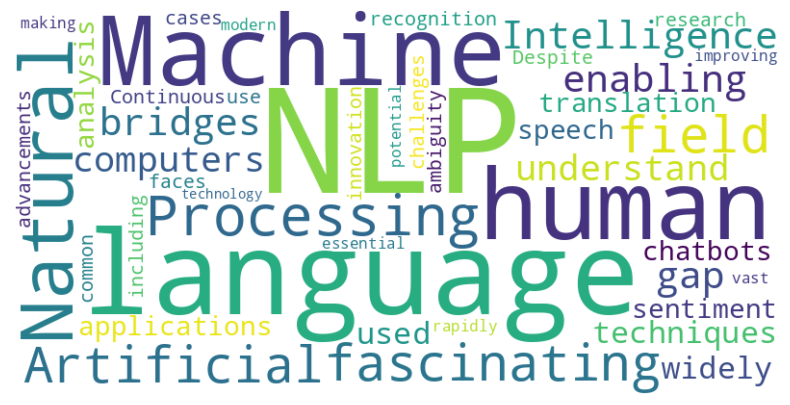

In [ ]:
plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.show()